# 03 — Extração de Features PDI

> **Etapa 2 do refactor.** Este notebook extrai **73 features handcrafted** das imagens,
> usando os mesmos splits definidos no notebook `02` (via `img_id`).
> A junção com os metadados acontece no notebook de modelagem.

## O que este notebook faz

1. Carrega os splits já definidos (`train/val/test.parquet`) para respeitar os mesmos
   índices sem redefinir splits.
2. Para cada imagem: redimensiona para 128×128 e extrai 5 grupos de features.
3. Documenta cada decisão de extração com justificativa.
4. Valida ausência de NaN/Inf e consistência de shapes.
5. Persiste `train_pdi.parquet`, `val_pdi.parquet`, `test_pdi.parquet` com `img_id`
   como chave de merge.

## O que este notebook NÃO faz

- Não redefine splits (herda do notebook 02).
- Não faz segmentação da lesão — features extraídas da imagem inteira.
- Não faz feature selection (RFE acontece no notebook de modelagem).
- Não normaliza as features PDI (StandardScaler aplicado no pipeline de modelagem).

## Saída final

```
data/processed/pdi/
├── train_pdi.parquet    # 73 features + img_id
├── val_pdi.parquet
├── test_pdi.parquet
└── pdi_info.json        # metadados: feature names, grupos, decisões
```

## 1. Setup

In [1]:
from pathlib import Path
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from PIL import Image
import cv2
from skimage.feature import local_binary_pattern, graycomatrix, graycoprops
from tqdm.auto import tqdm

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 140)

ROOT     = Path('..').resolve()
IMG_DIR  = ROOT / 'data' / 'raw' / 'images'
META_DIR = ROOT / 'data' / 'processed' / 'metadata'
PDI_DIR  = ROOT / 'data' / 'processed' / 'pdi'
PDI_DIR.mkdir(parents=True, exist_ok=True)

SEED        = 42
IMG_SIZE    = (128, 128)   # resolução para extração PDI
CLASS_ORDER = ['ACK', 'BCC', 'MEL', 'NEV', 'SCC', 'SEK']
CLASS_COLORS = {
    'ACK': '#bcbd22', 'BCC': '#d62728', 'MEL': '#9467bd',
    'NEV': '#2ca02c', 'SCC': '#ff7f0e', 'SEK': '#1f77b4'
}

print('Diretório de imagens:', IMG_DIR)
print('Diretório de saída  :', PDI_DIR)
print(f'Imagens disponíveis : {len(list(IMG_DIR.glob("*.png")))}')

Diretório de imagens: /home/icaro/Documentos/projeto_pad_ufes/data/raw/images
Diretório de saída  : /home/icaro/Documentos/projeto_pad_ufes/data/processed/pdi
Imagens disponíveis : 2298


## 2. Carregamento dos splits

Os splits foram definidos no notebook `02` por `StratifiedGroupKFold` agrupado
por `patient_id`. **Não redefinimos splits aqui** — apenas carregamos os `img_id`
de cada split para extrair features das imagens correspondentes.

A coluna `img_id` é a chave de merge entre metadados e PDI.

In [2]:
train_meta = pd.read_parquet(META_DIR / 'train.parquet')
val_meta   = pd.read_parquet(META_DIR / 'val.parquet')
test_meta  = pd.read_parquet(META_DIR / 'test.parquet')

print(f'Split  | Imagens')
print(f'-------|--------')
print(f'Train  | {len(train_meta)}')
print(f'Val    | {len(val_meta)}')
print(f'Test   | {len(test_meta)}')
print(f'Total  | {len(train_meta) + len(val_meta) + len(test_meta)}')
print()

# Verificar que todos os img_id existem em disco
all_ids = pd.concat([train_meta['img_id'], val_meta['img_id'], test_meta['img_id']])
missing_files = [img_id for img_id in all_ids if not (IMG_DIR / img_id).exists()]
assert len(missing_files) == 0, f'{len(missing_files)} imagens não encontradas em disco'
print(f'✅ Todos os {len(all_ids)} img_id encontrados em disco.')

Split  | Imagens
-------|--------
Train  | 1470
Val    | 368
Test   | 460
Total  | 2298

✅ Todos os 2298 img_id encontrados em disco.


## 3. Visualização das imagens por classe

Antes de extrair features, visualizamos amostras de cada classe para entender
o que estamos processando — e para calibrar expectativas sobre o que features
handcrafted conseguem capturar sem segmentação.

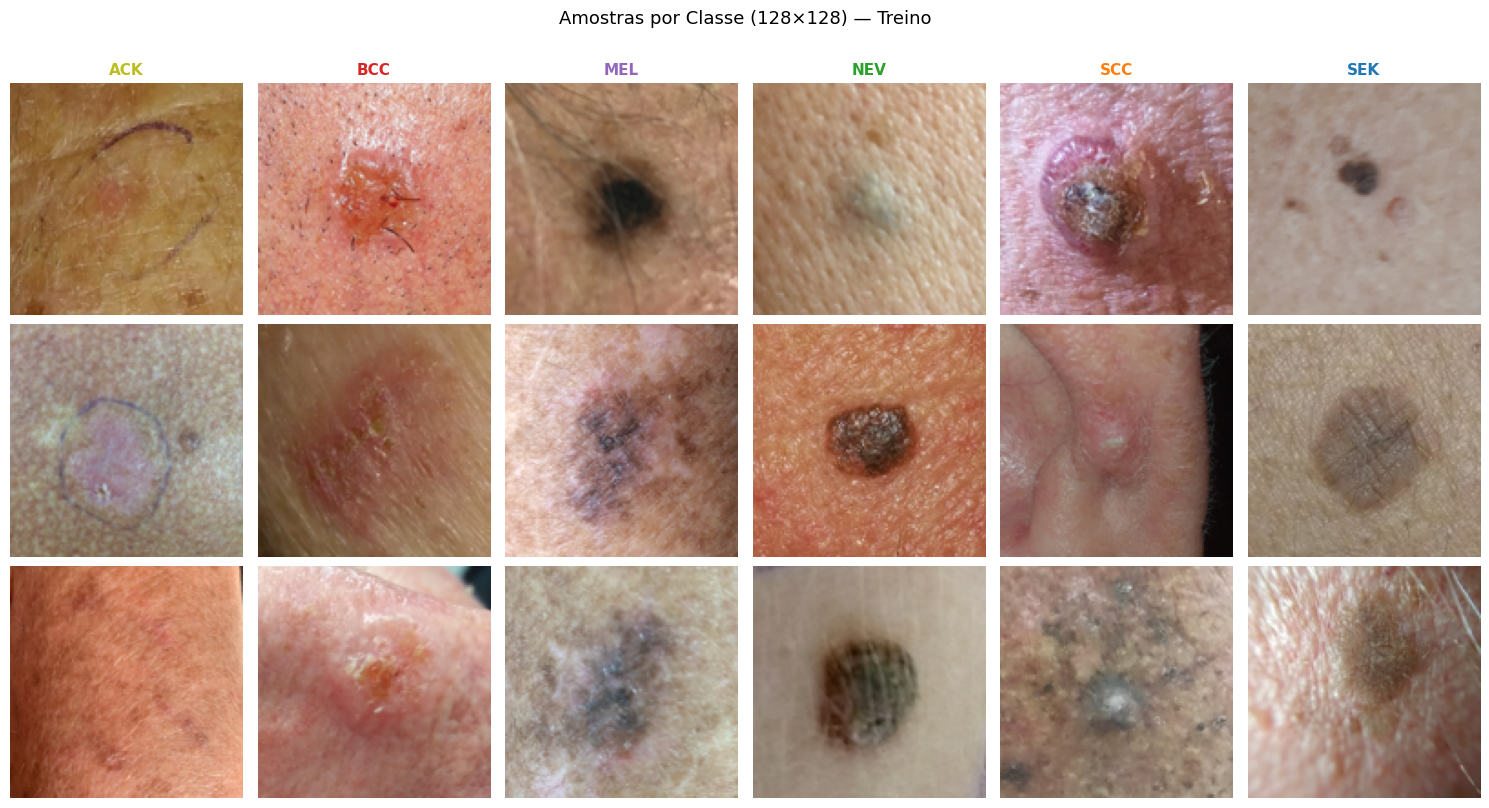

Observações:
  - Variação de iluminação, fundo e enquadramento entre imagens
  - Sem segmentação: features capturam lesão + pele ao redor
  - MEL e SCC são visualmente mais heterogêneos (classes mais difíceis)


In [3]:
fig, axes = plt.subplots(3, 6, figsize=(15, 8))

for col, cls in enumerate(CLASS_ORDER):
    subset = train_meta[train_meta['diagnostic'] == cls].sample(
        min(3, (train_meta['diagnostic'] == cls).sum()), random_state=SEED
    )
    for row, (_, row_data) in enumerate(subset.iterrows()):
        img = np.array(Image.open(IMG_DIR / row_data['img_id']).convert('RGB').resize(IMG_SIZE))
        axes[row, col].imshow(img)
        axes[row, col].axis('off')
        if row == 0:
            axes[row, col].set_title(cls, fontsize=11, fontweight='bold',
                                     color=CLASS_COLORS[cls])

plt.suptitle('Amostras por Classe (128×128) — Treino', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print('Observações:')
print('  - Variação de iluminação, fundo e enquadramento entre imagens')
print('  - Sem segmentação: features capturam lesão + pele ao redor')
print('  - MEL e SCC são visualmente mais heterogêneos (classes mais difíceis)')

## 4. Decisão 1 — Pré-processamento da imagem

**Resolução: 128×128**

Features de textura (GLCM, LBP, Gabor) operam sobre padrões locais de pixels —
não precisam de alta resolução para capturar esses padrões. 128×128 é suficiente
e mantém o custo computacional baixo.

Aumentar para 256×256 quadruplicaria o tempo de extração sem ganho esperado,
pois as features são estatísticas globais da imagem (médias, histogramas) —
não dependem de resolução fina.

**Interpolação: LANCZOS**

Preserva melhor bordas e texturas finas ao redimensionar do que BILINEAR ou
NEAREST — importante para features de borda (Canny, Sobel) e textura (GLCM).

**Conversão para RGB**

Algumas imagens do PAD-UFES estão em RGBA (canal alpha). `.convert('RGB')` garante
3 canais uniformes antes de qualquer extração.

In [4]:
def load_image(img_id: str) -> np.ndarray:
    """Carrega imagem, converte para RGB e redimensiona para 128×128."""
    img = Image.open(IMG_DIR / img_id).convert('RGB').resize(IMG_SIZE, Image.LANCZOS)
    return np.array(img, dtype=np.uint8)

# Verificação: shape e dtype corretos
sample_img = load_image(train_meta['img_id'].iloc[0])
assert sample_img.shape == (128, 128, 3), f'Shape inesperado: {sample_img.shape}'
assert sample_img.dtype == np.uint8
print(f'✅ Imagem carregada: shape={sample_img.shape}, dtype={sample_img.dtype}')
print(f'   Intervalo de valores: [{sample_img.min()}, {sample_img.max()}]')

✅ Imagem carregada: shape=(128, 128, 3), dtype=uint8
   Intervalo de valores: [18, 195]


## 5. Grupo 1 — Cor RGB + HSV (12 features)

**Features extraídas:** `mean` e `std` para cada um dos 6 canais: R, G, B, H, S, V.

**Por que RGB e HSV juntos?**
RGB e HSV descrevem a mesma imagem em espaços complementares:
- RGB captura intensidade por canal de cor primária
- H (matiz) e S (saturação) no HSV são **independentes do brilho** — mais robustos
  a variações de iluminação de smartphone
- V (valor) no HSV é próximo da luminosidade média do RGB — redundância esperada,
  que o RFE vai eliminar se for o caso

**Por que removemos skewness?**
Skewness captura a assimetria da distribuição de cor. Sem segmentação da lesão,
o histograma mistura pixels da lesão com pixels da pele ao redor — a assimetria
resultante captura mais a proporção lesão/fundo do que uma característica real
da lesão. Mean e std já capturam o essencial com sinal mais limpo.

In [5]:
def extract_color_features(img_rgb: np.ndarray) -> list:
    """12 features: mean e std por canal em RGB (3 canais) e HSV (3 canais)."""
    rgb = img_rgb.astype(np.float32)
    hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV).astype(np.float32)
    feats = []
    for arr in [rgb, hsv]:
        for ch in range(3):
            vals = arr[:, :, ch].ravel()
            feats += [float(np.mean(vals)), float(np.std(vals))]
    return feats  # 12 features

COLOR_FEATURE_NAMES = (
    [f'rgb_{ch}_{stat}' for ch in ['R', 'G', 'B'] for stat in ['mean', 'std']] +
    [f'hsv_{ch}_{stat}' for ch in ['H', 'S', 'V'] for stat in ['mean', 'std']]
)

# Sanidade
feats_test = extract_color_features(sample_img)
assert len(feats_test) == 12
print(f'Features de cor: {len(feats_test)}')
for name, val in zip(COLOR_FEATURE_NAMES, feats_test):
    print(f'  {name:15s} = {val:.4f}')

Features de cor: 12
  rgb_R_mean      = 162.0337
  rgb_R_std       = 14.0887
  rgb_G_mean      = 114.9219
  rgb_G_std       = 15.9050
  rgb_B_mean      = 73.7107
  rgb_B_std       = 14.6470
  hsv_H_mean      = 13.9735
  hsv_H_std       = 0.9086
  hsv_S_mean      = 139.8598
  hsv_S_std       = 17.7877
  hsv_V_mean      = 162.0337
  hsv_V_std       = 14.0887


## 6. Grupo 2 — GLCM (20 features)

**O que é GLCM:** Gray-Level Co-occurrence Matrix captura padrões de textura
medindo como pares de pixels com valores específicos de cinza aparecem juntos
na imagem, em uma determinada direção e distância.

**Features extraídas:** `contrast`, `dissimilarity`, `homogeneity`, `energy`,
`correlation` — para cada um dos 4 ângulos (0°, 45°, 90°, 135°) → **20 features**.

**Por que removemos ASM?**
`ASM = energy²` — são a mesma medida em escalas diferentes. Manter os dois
não adiciona informação; o RFE eliminaria um de qualquer forma.

**Por que separamos por ângulo em vez de tirar a média?**
O notebook 1 calculava a média das 4 orientações, destruindo informação direcional.
Lesões assimétricas — especialmente melanomas — têm textura diferente nos eixos
horizontal e vertical. Separar por ângulo preserva esse sinal; o RFE decide
quais orientações importam.

**Quantização em 64 níveis:** reduz `uint8` (256 níveis) para 64 via `gray // 4`.
Diminui o tamanho da matriz GLCM e o custo computacional sem perda significativa
de sinal de textura.

In [6]:
GLCM_ANGLES = [0, np.pi/4, np.pi/2, 3*np.pi/4]
GLCM_PROPS  = ['contrast', 'dissimilarity', 'homogeneity', 'energy', 'correlation']
GLCM_ANGLE_NAMES = ['0', '45', '90', '135']

def extract_glcm_features(gray: np.ndarray) -> list:
    """20 features: 5 propriedades × 4 ângulos, sem averaging direcional."""
    gray64 = (gray // 4).astype(np.uint8)  # quantização 256 → 64 níveis
    glcm   = graycomatrix(
        gray64,
        distances=[1],
        angles=GLCM_ANGLES,
        levels=64,
        symmetric=True,
        normed=True
    )
    feats = []
    for prop in GLCM_PROPS:
        values = graycoprops(glcm, prop).ravel()  # shape (1, 4) → 4 valores
        feats += values.tolist()
    return feats  # 20 features

GLCM_FEATURE_NAMES = [
    f'glcm_{prop}_{ang}'
    for prop in GLCM_PROPS
    for ang in GLCM_ANGLE_NAMES
]

gray_test = cv2.cvtColor(sample_img, cv2.COLOR_RGB2GRAY)
feats_test = extract_glcm_features(gray_test)
assert len(feats_test) == 20
print(f'Features GLCM: {len(feats_test)}')
for name, val in zip(GLCM_FEATURE_NAMES[:8], feats_test[:8]):
    print(f'  {name:30s} = {val:.6f}')
print('  ...')

Features GLCM: 20
  glcm_contrast_0                = 0.674766
  glcm_contrast_45               = 0.882572
  glcm_contrast_90               = 0.574988
  glcm_contrast_135              = 0.774320
  glcm_dissimilarity_0           = 0.523561
  glcm_dissimilarity_45          = 0.619071
  glcm_dissimilarity_90          = 0.476686
  glcm_dissimilarity_135         = 0.578523
  ...


## 7. Grupo 3 — LBP Multi-escala (20 features)

**O que é LBP:** Local Binary Pattern compara cada pixel com seus vizinhos
ao redor e gera um código binário. O histograma desses códigos descreve
a micro-textura da imagem.

**Por que multi-escala (R=1 e R=2)?**
O notebook 1 usava apenas R=1 (vizinhança de 1 pixel), capturando micro-textura.
Padrões relevantes em lesões cutâneas — pigmentação irregular, padrões vasculares,
estruturas típicas de melanoma — ocorrem em escalas maiores.

Adicionando R=2 com P=16 pontos de vizinhança, capturamos padrões em escala média
com custo baixo (+10 features). O RFE decide quais bins e qual escala importam.

**Método `uniform`:** reduz o histograma a P+2 bins agrupando padrões não-uniformes
(transições de bits > 2) em uma única categoria. Mais robusto a ruído que o LBP
completo.

In [7]:
def extract_lbp_features(gray: np.ndarray) -> list:
    """20 features: histograma LBP em R=1 (10 bins) e R=2 (10 bins)."""
    feats = []
    for R, P in [(1, 8), (2, 16)]:
        lbp  = local_binary_pattern(gray, P=P, R=R, method='uniform')
        hist, _ = np.histogram(lbp.ravel(), bins=10,
                               range=(0, P + 2), density=True)
        feats += hist.tolist()
    return feats  # 20 features

LBP_FEATURE_NAMES = (
    [f'lbp_r1_bin_{i}' for i in range(10)] +
    [f'lbp_r2_bin_{i}' for i in range(10)]
)

feats_test = extract_lbp_features(gray_test)
assert len(feats_test) == 20
print(f'Features LBP: {len(feats_test)}')
for name, val in zip(LBP_FEATURE_NAMES, feats_test):
    print(f'  {name:15s} = {val:.6f}')

Features LBP: 20
  lbp_r1_bin_0    = 0.066101
  lbp_r1_bin_1    = 0.081787
  lbp_r1_bin_2    = 0.056580
  lbp_r1_bin_3    = 0.091431
  lbp_r1_bin_4    = 0.102112
  lbp_r1_bin_5    = 0.108582
  lbp_r1_bin_6    = 0.086426
  lbp_r1_bin_7    = 0.099487
  lbp_r1_bin_8    = 0.127563
  lbp_r1_bin_9    = 0.179932
  lbp_r2_bin_0    = 0.068970
  lbp_r2_bin_1    = 0.030280
  lbp_r2_bin_2    = 0.021837
  lbp_r2_bin_3    = 0.030043
  lbp_r2_bin_4    = 0.019158
  lbp_r2_bin_5    = 0.036079
  lbp_r2_bin_6    = 0.027907
  lbp_r2_bin_7    = 0.035672
  lbp_r2_bin_8    = 0.071513
  lbp_r2_bin_9    = 0.214098


## 8. Grupo 4 — Bordas e Forma (5 features)

**Features extraídas:** `edge_density`, `sobel_mean`, `sobel_std`,
`asym_horizontal`, `asym_vertical`.

Estas são as features **mais defensáveis clinicamente** do pipeline —
mapeiam diretamente para os critérios ABCD de avaliação de lesões:

| Feature | Critério ABCD | Significado |
|---|---|---|
| `asym_horizontal`, `asym_vertical` | **A** — Assimetria | Lesão maligna tende a ser assimétrica |
| `edge_density` | **B** — Borda | Bordas irregulares indicam malignidade |
| `sobel_mean`, `sobel_std` | **B** — Borda | Magnitude e variação do gradiente |

**Decisão — Canny adaptativo (vs threshold fixo do notebook 1):**
O notebook 1 usava `threshold1=50, threshold2=150` fixos. Imagens de smartphone
têm variação enorme de contraste e iluminação — o mesmo threshold pode detectar
bordas demais numa imagem escura e nenhuma numa clara.

Usamos threshold baseado na mediana da imagem:
```
threshold1 = 0.66 × mediana
threshold2 = 1.33 × mediana
```
Isso adapta os thresholds à distribuição de cada imagem individualmente.

In [8]:
def extract_edge_features(gray: np.ndarray) -> list:
    """5 features: densidade Canny (adaptativa), magnitude Sobel (mean/std),
    assimetria horizontal e vertical."""
    # Canny com threshold adaptativo via mediana
    median = float(np.median(gray))
    t1 = int(max(0,   0.66 * median))
    t2 = int(min(255, 1.33 * median))
    edges = cv2.Canny(gray, threshold1=t1, threshold2=t2)

    # Sobel: magnitude do gradiente
    sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
    mag    = np.sqrt(sobelx**2 + sobely**2)

    # Assimetria: diferença de intensidade média entre metades
    h, w = gray.shape
    asym_h = float(np.abs(
        gray[:, :w//2].astype(float).mean() -
        gray[:, w//2:].astype(float).mean()
    ))
    asym_v = float(np.abs(
        gray[:h//2, :].astype(float).mean() -
        gray[h//2:, :].astype(float).mean()
    ))

    return [
        float((edges > 0).mean()),  # densidade de bordas (fração de pixels de borda)
        float(mag.mean()),          # magnitude média do gradiente
        float(mag.std()),           # desvio da magnitude
        asym_h,                     # assimetria horizontal (esquerda vs direita)
        asym_v,                     # assimetria vertical (cima vs baixo)
    ]

EDGE_FEATURE_NAMES = [
    'edge_density', 'sobel_mean', 'sobel_std', 'asym_horizontal', 'asym_vertical'
]

feats_test = extract_edge_features(gray_test)
assert len(feats_test) == 5
print(f'Features de borda: {len(feats_test)}')
for name, val in zip(EDGE_FEATURE_NAMES, feats_test):
    print(f'  {name:20s} = {val:.6f}')

Features de borda: 5
  edge_density         = 0.000000
  sobel_mean           = 14.238002
  sobel_std            = 11.556978
  asym_horizontal      = 14.871582
  asym_vertical        = 0.222900


## 9. Grupo 5 — Gabor (16 features)

**O que é Gabor:** filtros que detectam padrões de textura em orientações e
frequências específicas — capturam estruturas direcionais como estrias,
padrões vasculares e pigmentação linear.

**Configuração:** 4 orientações (0°, 45°, 90°, 135°) × 2 escalas
(fine: λ=5, σ=2 e coarse: λ=10, σ=4) × (mean + std) = **16 features**.

**Por que mantemos 4 orientações?**
O brainstorm propôs reduzir para 2 orientações. Com RFE no pipeline, essa
decisão pode ser feita empiricamente — se 45° e 135° forem redundantes com
0° e 90°, o RFE os elimina. Não há custo em manter as 4 orientações aqui
e deixar os dados decidirem.

**Duas escalas:** fine (λ=5) captura micro-texturas; coarse (λ=10) captura
padrões de média escala como pigmentação irregular.

In [9]:
GABOR_PARAMS = [
    (theta, lam, sig)
    for theta in [0, np.pi/4, np.pi/2, 3*np.pi/4]
    for (lam, sig) in [(5, 2), (10, 4)]   # fine (alta freq) e coarse (baixa freq)
]
GABOR_ANGLE_NAMES = ['0', '45', '90', '135']
GABOR_SCALE_NAMES = ['fine', 'coarse']

def extract_gabor_features(gray: np.ndarray) -> list:
    """16 features: mean e std da resposta de 8 filtros Gabor
    (4 orientações × 2 escalas)."""
    img_f = gray.astype(np.float64)
    feats = []
    for theta, lam, sig in GABOR_PARAMS:
        kernel = cv2.getGaborKernel((21, 21), sig, theta, lam, 0.5, 0, cv2.CV_64F)
        resp   = np.abs(cv2.filter2D(img_f, cv2.CV_64F, kernel))
        feats += [float(resp.mean()), float(resp.std())]
    return feats  # 16 features

GABOR_FEATURE_NAMES = [
    f'gabor_{ang}_{scale}_{stat}'
    for ang in GABOR_ANGLE_NAMES
    for scale in GABOR_SCALE_NAMES
    for stat in ['mean', 'std']
]

feats_test = extract_gabor_features(gray_test)
assert len(feats_test) == 16
print(f'Features Gabor: {len(feats_test)}')
for name, val in zip(GABOR_FEATURE_NAMES[:6], feats_test[:6]):
    print(f'  {name:25s} = {val:.4f}')
print('  ...')

Features Gabor: 16
  gabor_0_fine_mean         = 263.3273
  gabor_0_fine_std          = 35.9455
  gabor_0_coarse_mean       = 791.1561
  gabor_0_coarse_std        = 133.9838
  gabor_45_fine_mean        = 266.5528
  gabor_45_fine_std         = 36.0867
  ...


## 10. Função mestre de extração

Consolida os 5 grupos em uma única chamada. Ordem dos grupos:
Cor (12) → GLCM (20) → LBP (20) → Bordas (5) → Gabor (16) = **73 features**.

In [10]:
PDI_FEATURE_NAMES = (
    COLOR_FEATURE_NAMES +
    GLCM_FEATURE_NAMES  +
    LBP_FEATURE_NAMES   +
    EDGE_FEATURE_NAMES  +
    GABOR_FEATURE_NAMES
)

FEATURE_GROUPS = {
    'Cor RGB+HSV': COLOR_FEATURE_NAMES,
    'GLCM':        GLCM_FEATURE_NAMES,
    'LBP':         LBP_FEATURE_NAMES,
    'Bordas/Forma':EDGE_FEATURE_NAMES,
    'Gabor':       GABOR_FEATURE_NAMES,
}

print('Grupos de features PDI:')
for group, names in FEATURE_GROUPS.items():
    print(f'  {group:15s}: {len(names):2d} features')
print(f'  {"TOTAL":15s}: {len(PDI_FEATURE_NAMES):2d} features')
assert len(PDI_FEATURE_NAMES) == 73

def extract_pdi_features(img_id: str) -> np.ndarray:
    """Função mestre: carrega imagem e extrai as 73 features PDI."""
    img_rgb = load_image(img_id)
    gray    = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    feats = (
        extract_color_features(img_rgb) +
        extract_glcm_features(gray)     +
        extract_lbp_features(gray)      +
        extract_edge_features(gray)     +
        extract_gabor_features(gray)
    )
    return np.array(feats, dtype=np.float32)

# Sanidade em uma imagem
sample_feats = extract_pdi_features(train_meta['img_id'].iloc[0])
assert sample_feats.shape == (73,)
assert not np.isnan(sample_feats).any(), 'NaN encontrado!'
assert not np.isinf(sample_feats).any(), 'Inf encontrado!'
print(f'\n✅ Extração validada: shape={sample_feats.shape}, sem NaN/Inf')

Grupos de features PDI:
  Cor RGB+HSV    : 12 features
  GLCM           : 20 features
  LBP            : 20 features
  Bordas/Forma   :  5 features
  Gabor          : 16 features
  TOTAL          : 73 features

✅ Extração validada: shape=(73,), sem NaN/Inf


## 11. Extração — todos os splits

Extraímos features para os 3 splits **independentemente** —
não há fit/transform aqui, só extração determinística.

In [11]:
def extract_split(df_split: pd.DataFrame, split_name: str) -> pd.DataFrame:
    """Extrai features PDI para um split inteiro e retorna DataFrame."""
    features = []
    for img_id in tqdm(df_split['img_id'], desc=f'Extraindo {split_name}'):
        features.append(extract_pdi_features(img_id))
    X = np.stack(features)
    out = pd.DataFrame(X, columns=PDI_FEATURE_NAMES)
    out.insert(0, 'img_id', df_split['img_id'].values)
    return out

train_pdi = extract_split(train_meta, 'train')
val_pdi   = extract_split(val_meta,   'val')
test_pdi  = extract_split(test_meta,  'test')

print(f'\nShapes extraídos:')
print(f'  train_pdi : {train_pdi.shape}')
print(f'  val_pdi   : {val_pdi.shape}')
print(f'  test_pdi  : {test_pdi.shape}')

Extraindo test: 100%|██████████| 460/460 [00:33<00:00, 13.70it/s]


Shapes extraídos:
  train_pdi : (1470, 74)
  val_pdi   : (368, 74)
  test_pdi  : (460, 74)


## 12. Sanity checks

In [12]:
# 1. Shapes corretos
assert train_pdi.shape == (len(train_meta), 74), f'Shape inesperado: {train_pdi.shape}'  # 73 + img_id
assert val_pdi.shape   == (len(val_meta),   74)
assert test_pdi.shape  == (len(test_meta),  74)
print('✅ Shapes corretos')

# 2. Zero NaN e Inf
for name, df in [('train', train_pdi), ('val', val_pdi), ('test', test_pdi)]:
    feat_cols = PDI_FEATURE_NAMES
    n_nan = df[feat_cols].isnull().sum().sum()
    n_inf = np.isinf(df[feat_cols].values).sum()
    assert n_nan == 0, f'{name}: {n_nan} NaN encontrados'
    assert n_inf == 0, f'{name}: {n_inf} Inf encontrados'
print('✅ Zero NaN e Inf em todos os splits')

# 3. img_id é chave única e não tem overlap entre splits
ids_train = set(train_pdi['img_id'])
ids_val   = set(val_pdi['img_id'])
ids_test  = set(test_pdi['img_id'])
assert len(ids_train & ids_val)  == 0
assert len(ids_train & ids_test) == 0
assert len(ids_val   & ids_test) == 0
print('✅ Zero overlap de img_id entre splits')

# 4. img_id do PDI bate com img_id dos metadados (1-para-1)
assert list(train_pdi['img_id']) == list(train_meta['img_id'])
assert list(val_pdi['img_id'])   == list(val_meta['img_id'])
assert list(test_pdi['img_id'])  == list(test_meta['img_id'])
print('✅ img_id alinhado 1-para-1 com metadados')

# 5. Estatísticas básicas do treino (detecta valores absurdos)
print()
print('Estatísticas do train_pdi (primeiras 5 features):')
print(train_pdi[PDI_FEATURE_NAMES[:5]].describe().round(4))

✅ Shapes corretos
✅ Zero NaN e Inf em todos os splits
✅ Zero overlap de img_id entre splits
✅ img_id alinhado 1-para-1 com metadados

Estatísticas do train_pdi (primeiras 5 features):
       rgb_R_mean  rgb_R_std  rgb_G_mean  rgb_G_std  rgb_B_mean
count   1470.0000  1470.0000   1470.0000  1470.0000   1470.0000
mean     169.8844    22.9852    133.0002    25.9510    117.2229
std       26.1039    10.5990     23.3217     9.0762     25.8553
min       90.7660     4.3474     58.0017     9.3000     41.0574
25%      151.7385    15.3656    117.6470    19.3280    100.1711
50%      168.0594    20.7583    133.2112    24.4206    118.5047
75%      187.1772    28.5005    148.4745    30.8235    134.5959
max      244.4304    67.7208    216.9641    66.6685    211.0482


## 13. Visualização — Separabilidade por classe

Para cada grupo, plotamos as features mais representativas por classe.
O objetivo é verificar se as features têm poder discriminativo visual
antes de entrar no modelo.

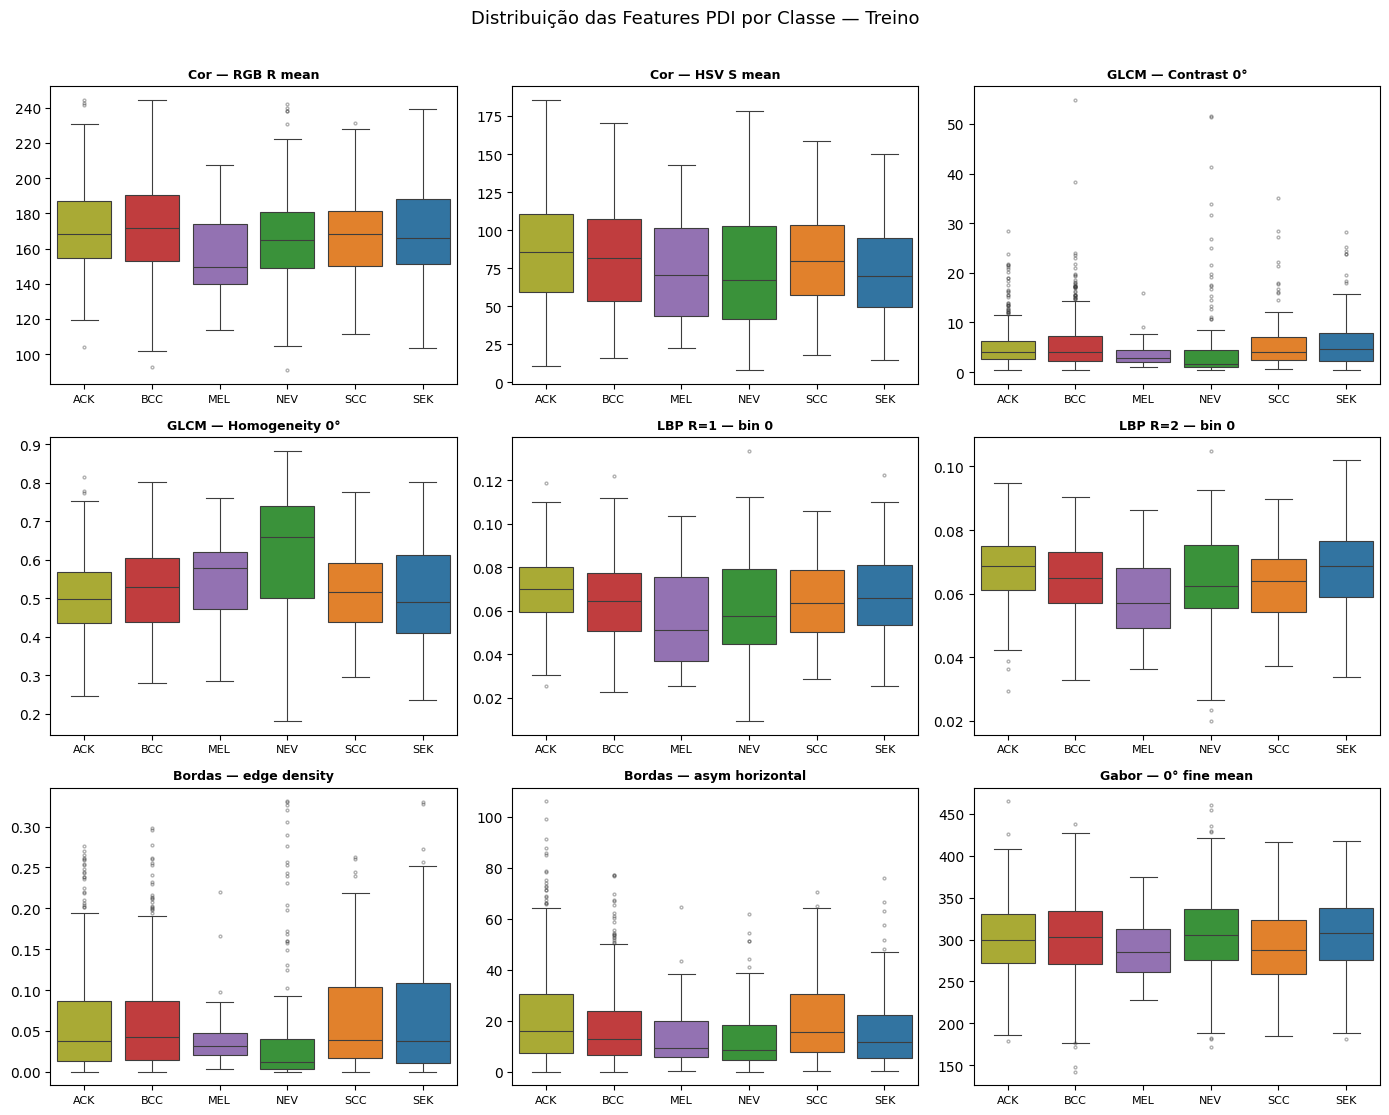

In [13]:
# Adiciona coluna de classe ao train_pdi para visualização
train_pdi_vis = train_pdi.copy()
train_pdi_vis['diagnostic'] = train_meta['diagnostic'].values

# Features representativas de cada grupo
REPRESENTATIVE_FEATURES = [
    ('rgb_R_mean',         'Cor — RGB R mean'),
    ('hsv_S_mean',         'Cor — HSV S mean'),
    ('glcm_contrast_0',    'GLCM — Contrast 0°'),
    ('glcm_homogeneity_0', 'GLCM — Homogeneity 0°'),
    ('lbp_r1_bin_0',       'LBP R=1 — bin 0'),
    ('lbp_r2_bin_0',       'LBP R=2 — bin 0'),
    ('edge_density',       'Bordas — edge density'),
    ('asym_horizontal',    'Bordas — asym horizontal'),
    ('gabor_0_fine_mean',  'Gabor — 0° fine mean'),
]

fig, axes = plt.subplots(3, 3, figsize=(14, 11))
axes = axes.flatten()
palette = [CLASS_COLORS[c] for c in CLASS_ORDER]

for ax, (feat, title) in zip(axes, REPRESENTATIVE_FEATURES):
    sns.boxplot(
        data=train_pdi_vis,
        x='diagnostic', y=feat,
        order=CLASS_ORDER,
        palette=palette,
        ax=ax,
        linewidth=0.8,
        flierprops=dict(marker='o', markersize=2, alpha=0.4)
    )
    ax.set_title(title, fontsize=9, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.tick_params(axis='x', labelsize=8)

plt.suptitle('Distribuição das Features PDI por Classe — Treino',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 14. Visualização — Correlação entre features PDI

Mapa de correlação entre as 73 features PDI no treino.
Revela redundâncias que o RFE vai tratar no notebook de modelagem.
Especialmente esperamos alta correlação dentro do grupo Gabor
(orientações similares) e entre RGB e HSV.

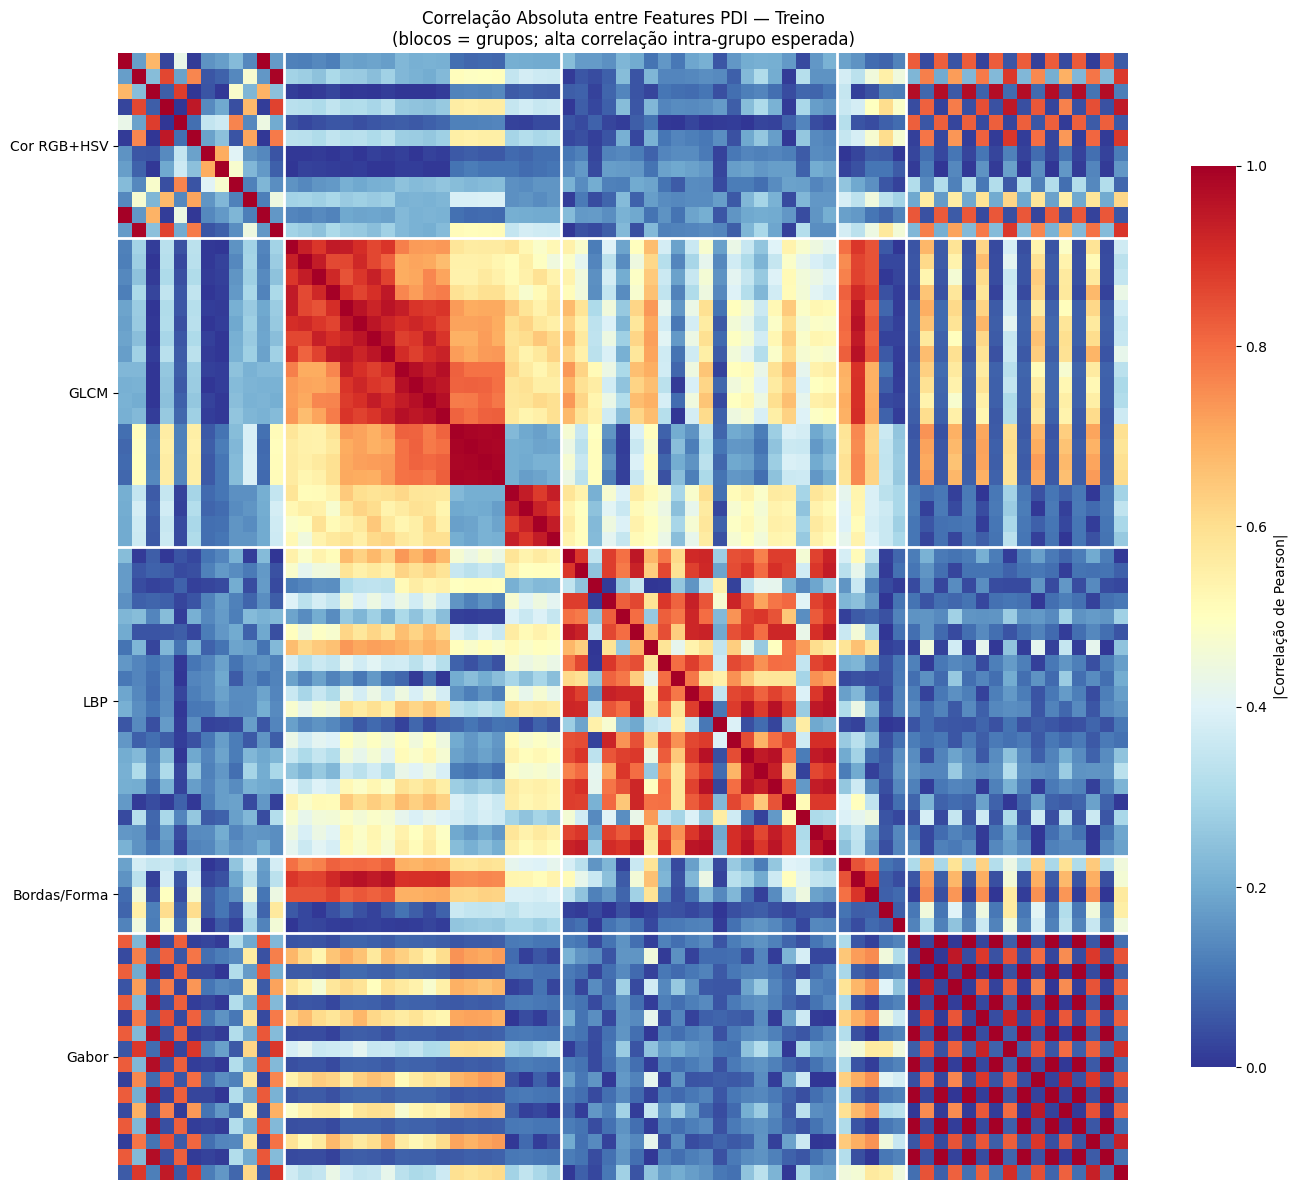

Pares com |correlação| > 0.9: 126
  gabor_135_fine_mean                 × gabor_135_coarse_mean               = 1.000
  gabor_45_coarse_mean                × gabor_135_coarse_mean               = 1.000
  gabor_45_fine_mean                  × gabor_45_coarse_mean                = 1.000
  gabor_45_fine_mean                  × gabor_90_fine_mean                  = 1.000
  gabor_90_fine_mean                  × gabor_135_fine_mean                 = 1.000
  gabor_45_coarse_mean                × gabor_90_fine_mean                  = 1.000
  gabor_90_fine_mean                  × gabor_135_coarse_mean               = 1.000
  gabor_45_coarse_mean                × gabor_135_fine_mean                 = 1.000
  gabor_45_fine_mean                  × gabor_135_coarse_mean               = 1.000
  gabor_45_fine_mean                  × gabor_135_fine_mean                 = 1.000


In [14]:
corr = train_pdi[PDI_FEATURE_NAMES].corr().abs()

# Boundaries dos grupos para linhas divisórias no heatmap
group_sizes = [len(v) for v in FEATURE_GROUPS.values()]
group_boundaries = np.cumsum(group_sizes)[:-1]

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    corr,
    ax=ax,
    cmap='RdYlBu_r',
    vmin=0, vmax=1,
    xticklabels=False,
    yticklabels=False,
    cbar_kws={'label': '|Correlação de Pearson|', 'shrink': 0.8}
)

# Linhas divisórias entre grupos
for b in group_boundaries:
    ax.axhline(b, color='white', linewidth=2)
    ax.axvline(b, color='white', linewidth=2)

# Labels dos grupos no eixo y
group_centers = np.array([0] + list(group_boundaries)) + np.array(group_sizes) / 2
ax.set_yticks(group_centers)
ax.set_yticklabels(list(FEATURE_GROUPS.keys()), fontsize=10)

ax.set_title('Correlação Absoluta entre Features PDI — Treino\n'
             '(blocos = grupos; alta correlação intra-grupo esperada)',
             fontsize=12)
plt.tight_layout()
plt.show()

# Pares com alta correlação (>0.9) — candidatos a remoção pelo RFE
high_corr = [
    (PDI_FEATURE_NAMES[i], PDI_FEATURE_NAMES[j], corr.iloc[i, j])
    for i in range(len(PDI_FEATURE_NAMES))
    for j in range(i+1, len(PDI_FEATURE_NAMES))
    if corr.iloc[i, j] > 0.9
]
print(f'Pares com |correlação| > 0.9: {len(high_corr)}')
for f1, f2, c in sorted(high_corr, key=lambda x: -x[2])[:10]:
    print(f'  {f1:35s} × {f2:35s} = {c:.3f}')

## 15. Visualização — Mutual Information das features PDI

MI rápido para ter uma visão inicial de quais features carregam mais sinal.
**Atenção:** o MI aqui é exploratório — a seleção final será feita por RFE
no notebook de modelagem, que é mais adequado para árvores.

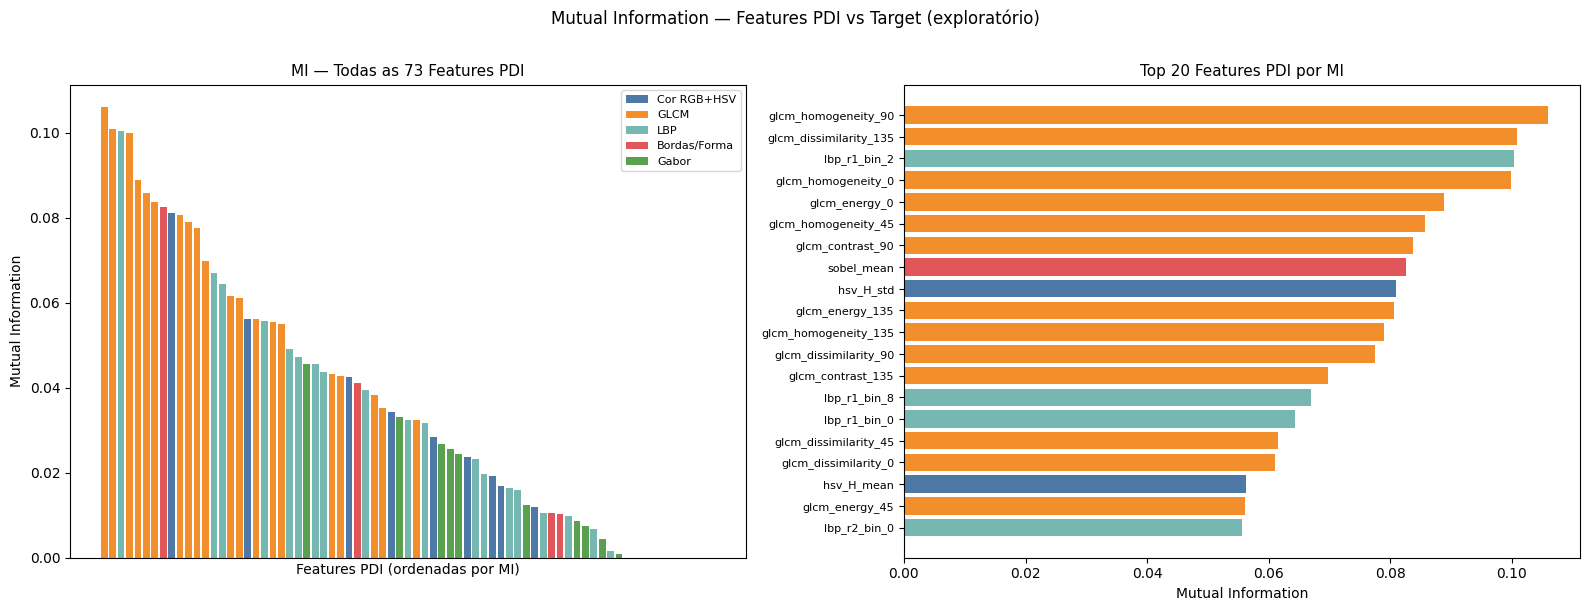

MI médio por grupo:
  Cor RGB+HSV    : 0.0262
  GLCM           : 0.0676
  LBP            : 0.0340
  Bordas/Forma   : 0.0289
  Gabor          : 0.0118


In [15]:
from sklearn.feature_selection import mutual_info_classif
import joblib

le = joblib.load(META_DIR / 'label_encoder.joblib')
y_train = le.transform(train_meta['diagnostic'].values)

mi_scores = mutual_info_classif(
    train_pdi[PDI_FEATURE_NAMES].values,
    y_train,
    discrete_features=False,
    random_state=SEED
)
mi_series = pd.Series(mi_scores, index=PDI_FEATURE_NAMES).sort_values(ascending=False)

# Cor por grupo
group_color_map = {
    'Cor RGB+HSV':  '#4e79a7',
    'GLCM':         '#f28e2b',
    'LBP':          '#76b7b2',
    'Bordas/Forma': '#e15759',
    'Gabor':        '#59a14f',
}
feat_to_group = {
    f: g for g, feats in FEATURE_GROUPS.items() for f in feats
}
bar_colors = [group_color_map[feat_to_group[f]] for f in mi_series.index]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: todas as features
axes[0].bar(range(len(mi_series)), mi_series.values, color=bar_colors, edgecolor='none')
axes[0].set_xticks([])
axes[0].set_xlabel('Features PDI (ordenadas por MI)', fontsize=10)
axes[0].set_ylabel('Mutual Information', fontsize=10)
axes[0].set_title('MI — Todas as 73 Features PDI', fontsize=11)
# Legenda dos grupos
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=g) for g, c in group_color_map.items()]
axes[0].legend(handles=legend_elements, fontsize=8)

# Plot 2: top 20
top20 = mi_series.head(20)
colors_top20 = [group_color_map[feat_to_group[f]] for f in top20.index]
axes[1].barh(range(20), top20.values[::-1], color=colors_top20[::-1], edgecolor='none')
axes[1].set_yticks(range(20))
axes[1].set_yticklabels(top20.index[::-1], fontsize=8)
axes[1].set_xlabel('Mutual Information', fontsize=10)
axes[1].set_title('Top 20 Features PDI por MI', fontsize=11)

plt.suptitle('Mutual Information — Features PDI vs Target (exploratório)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

# MI por grupo
print('MI médio por grupo:')
for group, feats in FEATURE_GROUPS.items():
    mean_mi = mi_series[feats].mean()
    print(f'  {group:15s}: {mean_mi:.4f}')

## 16. Persistência em disco

### Por que Parquet?

Parquet é um formato de arquivo binário colunar para dados tabulares.
Comparado ao CSV:

| Aspecto | CSV | Parquet |
|---|---|---|
| Tipos | Tudo vira string | Preserva float32, int, etc. |
| Tamanho | Grande | ~5× menor (comprimido) |
| Leitura | Lenta (parse texto) | Rápida (binário colunar) |
| Precisão | Perde casas decimais | Bit-perfect |

Para features PDI (float32) e features tabulares (mix de tipos), parquet
garante que o que foi salvo é exatamente o que é carregado.

In [16]:
train_pdi.to_parquet(PDI_DIR / 'train_pdi.parquet', index=False)
val_pdi.to_parquet(  PDI_DIR / 'val_pdi.parquet',   index=False)
test_pdi.to_parquet( PDI_DIR / 'test_pdi.parquet',  index=False)

pdi_info = {
    'n_features': len(PDI_FEATURE_NAMES),
    'feature_names': PDI_FEATURE_NAMES,
    'feature_groups': {g: feats for g, feats in FEATURE_GROUPS.items()},
    'img_size': list(IMG_SIZE),
    'decisions': {
        'color': 'mean+std por canal RGB e HSV (sem skewness)',
        'glcm':  '5 props × 4 ângulos separados (sem ASM, sem averaging)',
        'lbp':   'R=1 P=8 + R=2 P=16, 10 bins cada (multi-escala)',
        'edges': 'Canny adaptativo (threshold via mediana) + Sobel + assimetria',
        'gabor': '4 orientações × 2 escalas × (mean+std)',
    },
    'merge_key': 'img_id',
    'n_train': len(train_pdi),
    'n_val':   len(val_pdi),
    'n_test':  len(test_pdi),
}

with open(PDI_DIR / 'pdi_info.json', 'w') as f:
    json.dump(pdi_info, f, indent=2)

print('✅ Artefatos salvos em', PDI_DIR)
for p in sorted(PDI_DIR.iterdir()):
    size = p.stat().st_size
    unit = 'KB' if size < 1e6 else 'MB'
    val  = size/1024 if size < 1e6 else size/1e6
    print(f'  {p.name:25s}  {val:>7.1f} {unit}')

✅ Artefatos salvos em /home/icaro/Documentos/projeto_pad_ufes/data/processed/pdi
  pdi_info.json                  4.0 KB
  test_pdi.parquet             208.7 KB
  train_pdi.parquet            563.8 KB
  val_pdi.parquet              175.8 KB


## 17. Sanity check final — verificar parquets em disco

In [17]:
tr = pd.read_parquet(PDI_DIR / 'train_pdi.parquet')
vl = pd.read_parquet(PDI_DIR / 'val_pdi.parquet')
ts = pd.read_parquet(PDI_DIR / 'test_pdi.parquet')

# Shapes
assert tr.shape == (len(train_meta), 74)
assert vl.shape == (len(val_meta),   74)
assert ts.shape == (len(test_meta),  74)
print('✅ Shapes corretos nos parquets')

# Zero NaN
for name, d in [('train', tr), ('val', vl), ('test', ts)]:
    assert d[PDI_FEATURE_NAMES].isnull().sum().sum() == 0
print('✅ Zero NaN nos parquets')

# img_id único por split
for name, d in [('train', tr), ('val', vl), ('test', ts)]:
    assert d['img_id'].is_unique, f'{name}: img_id duplicado'
print('✅ img_id único em cada split')

# Merge test: PDI + metadados por img_id
merged = tr.merge(train_meta[['img_id', 'diagnostic']], on='img_id', how='inner')
assert len(merged) == len(tr), 'Merge perdeu linhas'
print('✅ Merge PDI × metadados por img_id funciona sem perda')

✅ Shapes corretos nos parquets
✅ Zero NaN nos parquets
✅ img_id único em cada split
✅ Merge PDI × metadados por img_id funciona sem perda


## 18. Resumo executivo

```
┌─ INPUT ──────────────────────────────────────────────────┐
│  data/raw/images/  (2298 imagens PNG)                    │
│  data/processed/metadata/train|val|test.parquet          │
│  (splits herdados do notebook 02 via img_id)             │
└──────────────────────────────────────────────────────────┘
                         ↓
┌─ DECISÕES APLICADAS ─────────────────────────────────────┐
│  RESIZE     128×128 LANCZOS                              │
│  COR        mean+std RGB+HSV (sem skewness)    12 feats  │
│  GLCM       5 props × 4 ângulos (sem ASM)      20 feats  │
│  LBP        R=1 + R=2 multi-escala             20 feats  │
│  BORDAS     Canny adaptativo + Sobel + asym     5 feats  │
│  GABOR      4 orient × 2 escalas               16 feats  │
│  TOTAL                                         73 feats  │
│                                                          │
│  SEM segmentação (imagem inteira)                        │
│  SEM normalização (StandardScaler no modelagem)          │
│  SEM feature selection (acontece no notebook 04)         │
└──────────────────────────────────────────────────────────┘
                         ↓
┌─ OUTPUT ─────────────────────────────────────────────────┐
│  data/processed/pdi/                                     │
│    train_pdi.parquet  val_pdi.parquet  test_pdi.parquet  │
│    pdi_info.json                                         │
└──────────────────────────────────────────────────────────┘
```

---

## Pipeline dos próximos notebooks

```
┌─ 04_juncao_features.ipynb ───────────────────────────────┐
│  Junta metadados + PDI por img_id                        │
│  Aplica StandardScaler nas features PDI                  │
│  Seleção simples por importância (DT rápida)             │
│  Compara todos os atributos vs selecionados              │
│                                                          │
│  OUTPUT: train_full.parquet  val_full.parquet            │
│          test_full.parquet   feature_selector.joblib     │
└──────────────────────────────────────────────────────────┘
                         ↓
┌─ 05_modelos_ml.ipynb ────────────────────────────────────┐
│  DT  — tuning de hiperparâmetros (RandomizedSearchCV)    │
│  MLP — tuning de hiperparâmetros (RandomizedSearchCV)    │
│  Avaliação: F1-macro + matriz de confusão por classe     │
│  Importância dos atributos (feature_importance da DT)    │
└──────────────────────────────────────────────────────────┘
                         ↓
┌─ 06_cnn.ipynb ───────────────────────────────────────────┐
│  EfficientNetB0 pré-treinado (ImageNet)                  │
│  Stage 1: backbone congelado                             │
│  Stage 2: fine-tuning últimos blocos                     │
│  Loss ponderada por classe (sem duplo balanceamento)     │
│  Augmentation agressiva + calibração de threshold        │
└──────────────────────────────────────────────────────────┘
                         ↓
┌─ 07_resultados.ipynb ────────────────────────────────────┐
│  Comparação final: DT vs MLP vs CNN                      │
│  F1-macro + F1 por classe + AUC-ROC                      │
│  Matriz de confusão lado a lado                          │
│  Análise de erros: maligno→benigno vs benigno→maligno    │
│  Discussão: qual paradigma performa melhor e por quê     │
└──────────────────────────────────────────────────────────┘
```
